## Multi-modality with CLIP

Neural network trained on a variety of (image, text) pairs. Can be instructed in natural language to predict the most relevant text snippet given an image.

![CLIP training](https://github.com/openai/CLIP/blob/main/CLIP.png?raw=true)

Can also use CLIP models to produce embeddings of images and texts into a shared vector space.

[Read more](https://openai.com/research/clip) | [GitHub repo](https://github.com/openai/CLIP)

### Set-up

#### Load models

In [1]:
from sentence_transformers import SentenceTransformer
from PIL import Image
import requests
from pathlib import Path

# The original clip-ViT-B-32 for encoding images
img_model = SentenceTransformer('clip-ViT-B-32')

# The second model is aligned - i.e. it maps to the same vector space as the original model
text_model = SentenceTransformer('sentence-transformers/clip-ViT-B-32-multilingual-v1')

# Read more about the models at:
# https://huggingface.co/sentence-transformers/clip-ViT-B-32
# https://huggingface.co/sentence-transformers/clip-ViT-B-32-multilingual-v1

c:\Users\akmal\anaconda3\envs\weaviate_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


#### data

In [34]:
import requests
from PIL import Image


TMDB_API_KEY = "450707599ec0f019f7262f96096aea28"
TMDB_BASE_URL = "https://api.themoviedb.org/3"
IMAGE_BASE_URL = "https://image.tmdb.org/t/p/w500"

# Ambil daftar film populer
response = requests.get(f"{TMDB_BASE_URL}/movie/popular?api_key={TMDB_API_KEY}")
movies = response.json()['results']

In [36]:
print(len(movies))

20


In [37]:
all_movies = []

for page in range(1, 101):  # page 1 sampai 3
    response = requests.get(
        f"{TMDB_BASE_URL}/movie/popular",
        params={"api_key": TMDB_API_KEY, "page": page}
    )
    page_movies = response.json()['results']
    all_movies.extend(page_movies)

print(f"Total film yang diambil: {len(all_movies)}")


Total film yang diambil: 2000


In [38]:
import json

with open("all_movies.json", "w", encoding="utf-8") as f:
    json.dump(all_movies, f, ensure_ascii=False, indent=2)


#### Helper functions

In [2]:
# Helper function for loading an image or URL
def load_image(url_or_path):
    if url_or_path.startswith("http://") or url_or_path.startswith("https://"):
        return Image.open(requests.get(url_or_path, stream=True).raw)
    else:
        return Image.open(url_or_path)

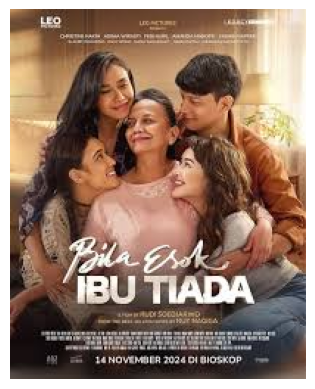

In [29]:
from PIL import Image
import matplotlib.pyplot as plt

# Uji fungsi dengan path lokal
img = load_image("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQhjajyOS3zgZsSbmoIBVFBXVmNulW9FdQjjw&s")
plt.imshow(img)
plt.axis('off')
plt.show()


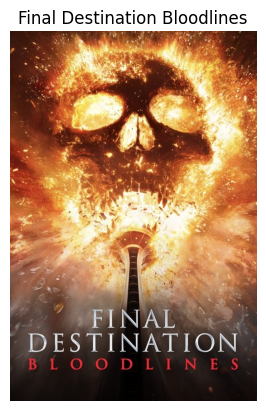

In [39]:
movie = all_movies[0]
IMAGE_BASE_URL = "https://image.tmdb.org/t/p/w500"
poster_url = IMAGE_BASE_URL + movie["poster_path"]

img = load_image(poster_url)

plt.imshow(img)
plt.axis('off')
plt.title(movie["title"])
plt.show()

In [3]:
import base64

# Helper function to convert a file to base64 representation
def to_base64(path):
    with open(path, 'rb') as file:
        return base64.b64encode(file.read()).decode('utf-8')

In [ ]:
# weaviate tidak bisa menerima biner langsung jadi harus diubah ke str teks ASCII
# sama kayak JSON(misalnya lewat REST API)
# Tes fungsi to_base64
b64_str = to_base64("data/posters/5_poster.jpg")

# Tampilkan hasilnya (hanya sebagian agar tidak terlalu panjang)
print("Base64 Output (first 100 chars):")
print(b64_str[:100])

# Cek tipe dan panjang
print("Tipe:", type(b64_str))      # Harusnya <class 'str'>
print("Panjang:", len(b64_str))    # Panjang string Base64


Base64 Output (first 100 chars):
/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAYGBgYGBgcICAcKCgkKCg4NDAwNDhUPEA8QDxUgFBgUFBgUIB0jHBocIx0zKCQkKDM7
Tipe: <class 'str'>
Panjang: 64256


In [4]:
# Helper function for showing images in Jupyter (using Matplotlib)
import matplotlib.pyplot as plt

def show_images(response, src_img=None):
    # Load all 3 images into a list and show them in Jupyter with matplotlib
    images = [load_image(o.properties["file_path"]) for o in response.objects]
    if src_img:
        images = [src_img] + images
    _, axs = plt.subplots(1, len(images), figsize=(20, 10))
    for i, img in enumerate(images):
        axs[i].imshow(img)
        axs[i].axis('off')
    return None

#### Load data

In [5]:
# Use local paths for the dataset
# Data from TMDB; gathered through their API. (https://www.themoviedb.org/)
poster_img_dir = Path("data/posters")
poster_img_paths = [str(p) for p in poster_img_dir.glob("*.jpg")]

In [6]:
print(len(poster_img_paths))

90


In [7]:
API_KEY = "NG5pYzl3V3FubnpiN2lvRF9QY1UyNnZydjFpQ0cxYlJ2RlhJaUZUOXNoeDNOOER5anFNQkhCSWY1VHBBPV92MjAw"
URL = "rv4h7pxs0sadpc1fg4g7q.c0.asia-southeast1.gcp.weaviate.cloud"

### Connect to Weaviate

In [14]:
import weaviate
import weaviate.classes as wvc
from weaviate.util import generate_uuid5

client = weaviate.connect_to_local(port=8080, grpc_port=50051)# Downloads Weaviate and directly spins up an instance
# Could also be a local instance or a remote instance
# client = weaviate.connect_to_local(port=8070, grpc_port=50041)  # Local instance (e.g. Kubernetes or Docker)
# client = weaviate.connect_to_wcs()  # Weaviate Cloud Service (SaaS)

WeaviateConnectionError: Connection to Weaviate failed. Details: Error: [WinError 10061] No connection could be made because the target machine actively refused it. 
Is Weaviate running and reachable at http://localhost:8080?

In [9]:
import weaviate
from weaviate.auth import AuthApiKey

client = weaviate.connect_to_wcs(
    cluster_url=URL,
    auth_credentials=AuthApiKey(API_KEY),
)

print("Connected:", client.is_ready())  # Harus True kalau berhasil


C:\Users\akmal\AppData\Local\Temp\ipykernel_26484\92729179.py:4: DeprecatedWarning: connect_to_wcs is deprecated as of 4.6.2. 
This method is deprecated and will be removed in a future release. Use :func:`connect_to_weaviate_cloud` instead.

  client = weaviate.connect_to_wcs(
c:\Users\akmal\anaconda3\envs\weaviate_env\Lib\site-packages\deprecation.py:260: DeprecationWarning: This method is deprecated and will be removed in a future release. Use `connect_to_weaviate_cloud` instead.
  return function(*args, **kwargs)


Connected: True


In [10]:
coll_name = "MultiModal"

### Create a collection

In [12]:
import weaviate.classes as wvc

# Create the collection
client.collections.create(
    name=coll_name,
    vectorizer_config=wvc.config.Configure.Vectorizer.none(),  # You could use "multi2vec-clip" or "multi2vec-bind" for example if running a local instance.
    generative_config=wvc.config.Configure.Generative.openai(),
    properties=[
        wvc.config.Property(
            name="file_path",
            data_type=wvc.config.DataType.TEXT
        ),
        wvc.config.Property(
            name="img_source",
            data_type=wvc.config.DataType.TEXT
        ),
        wvc.config.Property(
            name="image",
            data_type=wvc.config.DataType.BLOB
        ),
    ]
)

In [41]:
import weaviate.classes as wvc

coll_name = "TMDBMovies"

client.collections.create(
    name=coll_name,
    vectorizer_config=wvc.config.Configure.Vectorizer.none(),
    generative_config=wvc.config.Configure.Generative.openai(),
    properties=[
        wvc.config.Property(name="file_path", data_type=wvc.config.DataType.TEXT),
        wvc.config.Property(name="img_source", data_type=wvc.config.DataType.TEXT),
        wvc.config.Property(name="image", data_type=wvc.config.DataType.BLOB),
        wvc.config.Property(name="title", data_type=wvc.config.DataType.TEXT),
        wvc.config.Property(name="overview", data_type=wvc.config.DataType.TEXT),
    ]
)


### Add data to the collection

In [14]:
import time
from weaviate.util import generate_uuid5

# Get the collection
mm_coll = client.collections.get(coll_name)

# Add the objects using a batch process
counter = 0
start_time = time.time()
with mm_coll.batch.dynamic() as batch:
    for img_set in [
        (poster_img_paths, "TMDB"),
    ]:
        for img_path in img_set[0][:100]:
            # Get the vector from the image model
            vector = img_model.encode([load_image(img_path)])[0].tolist()
            img_b64 = to_base64(img_path)

            # Add the object to the batch
            batch.add_object(
                properties={
                    "file_path": img_path,
                    "image": img_b64,
                    "img_source": img_set[1]
                },
                vector=vector,  # Specify the vector
                uuid=generate_uuid5(img_path)
            )
            counter += 1
            if counter % 500 == 0:
                print(f"Added {counter} objects. {time.time() - start_time} seconds for last 500 objects.")
                start_time = time.time()

In [33]:
counter

90

In [42]:
mm_coll = client.collections.get(coll_name)

import time
counter = 0
start_time = time.time()

with mm_coll.batch.dynamic() as batch:
    for movie in all_movies:  # ganti jumlah sesuai kebutuhan
        poster_path = movie.get("poster_path")
        if not poster_path:
            continue  # skip kalau tidak ada poster

        full_image_url = IMAGE_BASE_URL + poster_path
        title = movie.get("title", "No Title")
        overview = movie.get("overview", "No Overview")

        try:
            img = load_image(full_image_url)
            vector = img_model.encode([img])[0].tolist()
            img_b64 = to_base64(full_image_url)

            batch.add_object(
                properties={
                    "file_path": full_image_url,
                    "img_source": "TMDB",
                    "image": img_b64,
                    "title": title,
                    "overview": overview
                },
                vector=vector,
                uuid=generate_uuid5(full_image_url)
            )

            counter += 1
            if counter % 25 == 0:
                print(f"Uploaded {counter} posters in {time.time() - start_time:.2f} seconds")
                start_time = time.time()

        except Exception as e:
            print(f"Error on '{title}': {e}")


Error on 'Final Destination Bloodlines': [Errno 22] Invalid argument: 'https://image.tmdb.org/t/p/w500/6WxhEvFsauuACfv8HyoVX6mZKFj.jpg'
Error on 'The Twisters': [Errno 22] Invalid argument: 'https://image.tmdb.org/t/p/w500/8OP3h80BzIDgmMNANVaYlQ6H4Oc.jpg'
Error on 'Lilo & Stitch': [Errno 22] Invalid argument: 'https://image.tmdb.org/t/p/w500/7c5VBuCbjZOk7lSfj9sMpmDIaKX.jpg'
Error on 'Distant': [Errno 22] Invalid argument: 'https://image.tmdb.org/t/p/w500/czh8HOhsbBUKoKsmRmLQMCLHUev.jpg'
Error on 'Crazy Lizard': [Errno 22] Invalid argument: 'https://image.tmdb.org/t/p/w500/9TFaFsSXedaALXTzba349euDeoY.jpg'
Error on 'How to Train Your Dragon': [Errno 22] Invalid argument: 'https://image.tmdb.org/t/p/w500/q5pXRYTycaeW6dEgsCrd4mYPmxM.jpg'
Error on 'Candle in the Tomb: The Worm Valley': [Errno 22] Invalid argument: 'https://image.tmdb.org/t/p/w500/7Hk1qxAvZi9H9cfBb4iHkoGjapH.jpg'
Error on 'KPop Demon Hunters': [Errno 22] Invalid argument: 'https://image.tmdb.org/t/p/w500/43c1efKzA1kigNzY0HBz

KeyboardInterrupt: 

## Queries!

### Get the collection object

In [15]:
mm_coll = client.collections.get(coll_name)

### Search objects by text

Showing movie posters closest to query: 'jumanji'


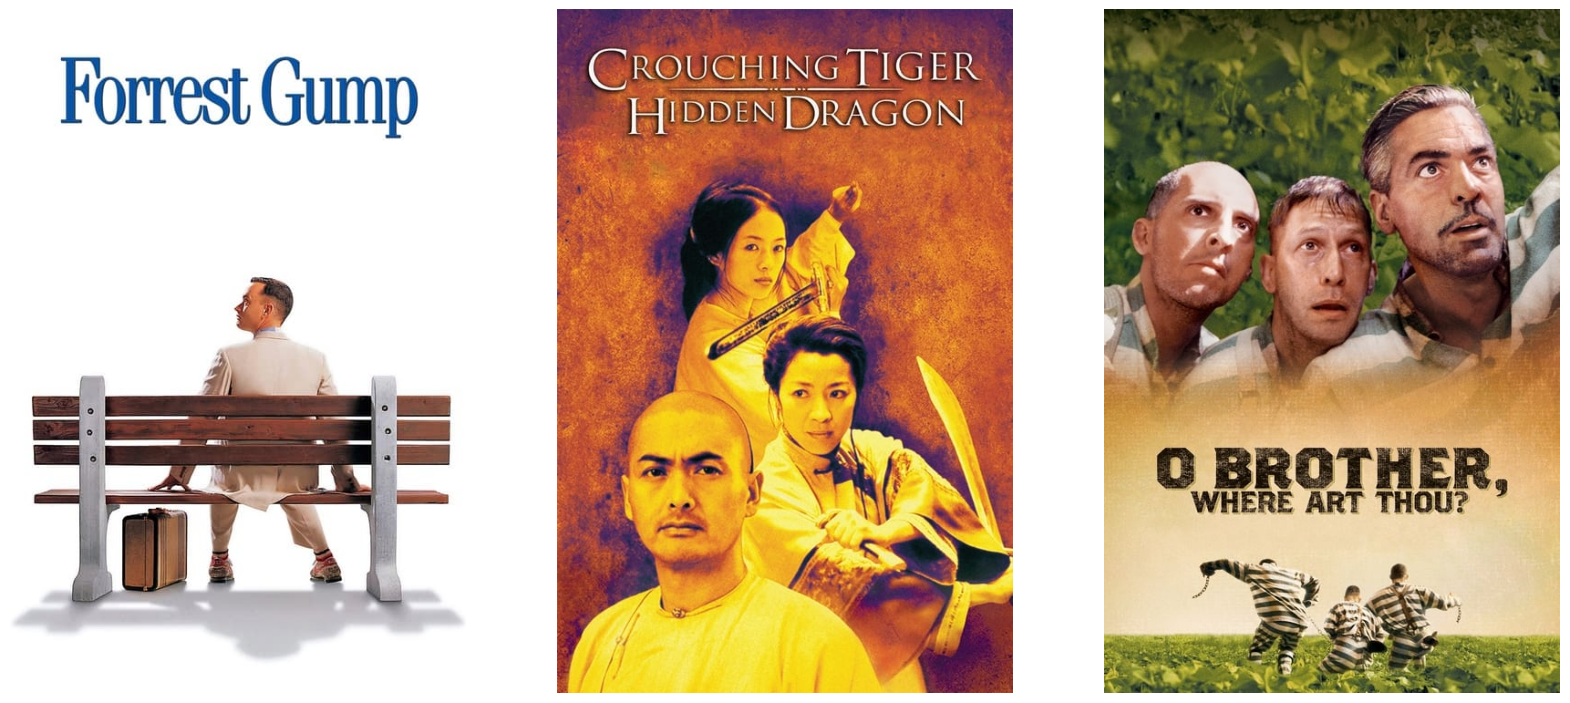

In [21]:
query = "jumanji"
text_vec = text_model.encode([query])[0].tolist()

response = mm_coll.query.near_vector(
    near_vector=text_vec,
    return_properties=["image", "file_path"],
    filters=wvc.query.Filter.by_property("img_source").equal("TMDB"),
    limit=3
)

print(f"Showing movie posters closest to query: '{query}'")
show_images(response)


### Search objects by image

Showing movie posters closest to the first (left-side) image


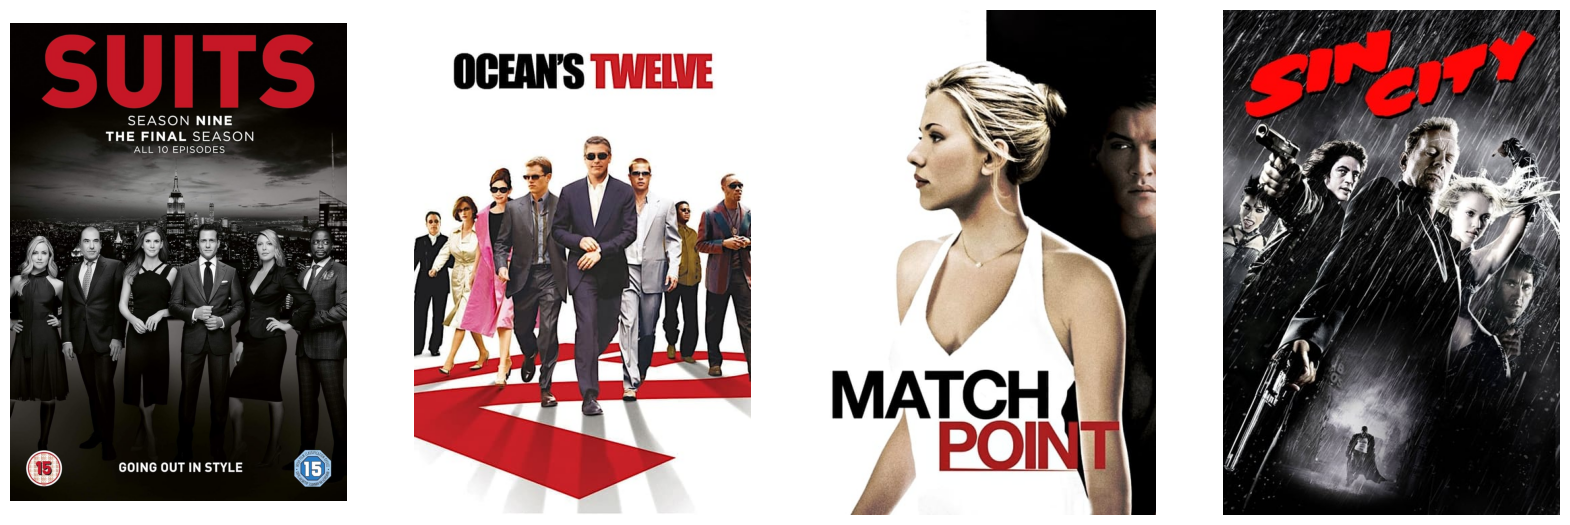

In [22]:
src_img = load_image("data/query/tv_suits_10.jpg")
img_vec = img_model.encode([src_img])[0].tolist()

response = mm_coll.query.near_vector(
    near_vector=img_vec,
    return_properties=["image", "file_path"],
    filters=wvc.query.Filter.by_property("img_source").equal("TMDB"),
    limit=3
)

print(f"Showing movie posters closest to the first (left-side) image")
show_images(response, src_img)

Showing movie posters closest to query: 'red cars'


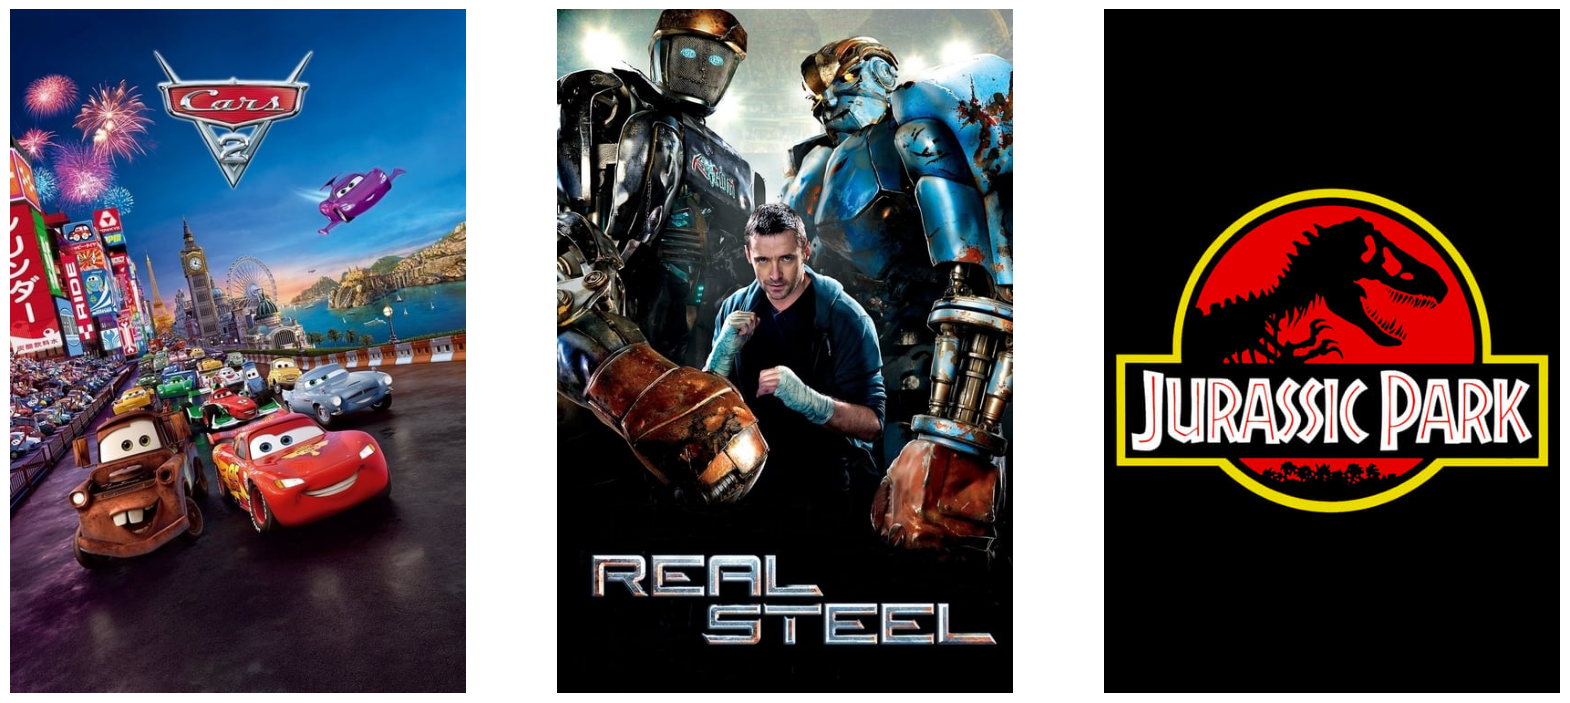

In [14]:
query = "red cars"
text_vec = text_model.encode([query])[0].tolist()

response = mm_coll.query.near_vector(
    near_vector=text_vec,
    return_properties=["image", "file_path"],
    filters=wvc.query.Filter.by_property("img_source").equal("TMDB"),
    limit=3
)

print(f"Showing movie posters closest to query: '{query}'")
show_images(response)